In [24]:
import pandas as pd 

sales = pd.read_csv("sales.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")

print (f"sales Shape  {sales.shape}  ")
print (f"customers Shape  {customers.shape}  ")
print (f"products Shape  {products.shape}  ")

full_data["month"] = pd.to_datetime(full_data["date"]).dt.to_period("M")


sales.info()

print ("\n Sales Table")
sales.head()

sales Shape  (1000, 5)  
customers Shape  (52, 4)  
products Shape  (20, 4)  
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   order_id     1000 non-null   str  
 1   date         1000 non-null   str  
 2   customer_id  1000 non-null   str  
 3   product_id   1000 non-null   str  
 4   quantity     1000 non-null   int64
dtypes: int64(1), str(4)
memory usage: 39.2 KB

 Sales Table


,order_id,date,customer_id,product_id,quantity
0,O00001,2024-10-31,C999,P019,2
1,O00002,2024-03-14,C999,P014,1
2,O00003,2024-10-21,C999,P004,1
3,O00004,2024-01-03,C999,P003,3
4,O00005,2024-10-18,C999,P018,4


**TASK 01 Build the master table**

• Identify the keys: which column links sales to customers? Which links sales to products?

In [ ]:
# sales and customers are  link by customer id 

# sales and product are linked by the product id 



• Merge all three tables into one master table, so every sale row carries its customer's region and its product's
name, category, and price.

In [7]:
full_data  =  (sales.merge (customers , on= 'customer_id' , how = 'left')
                    .merge (products , on= 'product_id', how = 'left' ))


full_data.head(10)

,order_id,date,customer_id,product_id,quantity,customer_name,region,signup_year,product_name,category,unit_price
0,O00001,2024-10-31,C999,P019,2,NaN,NaN,NaN,Microphone,Electronics,110
1,O00002,2024-03-14,C999,P014,1,NaN,NaN,NaN,Water Bottle,Accessories,20
2,O00003,2024-10-21,C999,P004,1,NaN,NaN,NaN,Monitor,Electronics,250
3,O00004,2024-01-03,C999,P003,3,NaN,NaN,NaN,Keyboard,Electronics,45
4,O00005,2024-10-18,C999,P018,4,NaN,NaN,NaN,Speaker,Electronics,90
5,O00006,2024-10-15,C010,P006,2,Customer_10,North,2023.0,Headphones,Electronics,120
6,O00007,2024-10-12,C013,P016,5,Customer_13,East,2022.0,Cable Set,Electronics,30
7,O00008,2024-08-31,C046,P003,2,Customer_46,West,2022.0,Keyboard,Electronics,45
8,O00009,2024-06-21,C048,P006,5,Customer_48,West,2023.0,Headphones,Electronics,120
9,O00010,2024-09-15,C003,P006,2,Customer_3,East,2022.0,Headphones,Electronics,120


• Compute a revenue column (quantity times unit price).

In [ ]:
full_data['revenue'] = full_data['quantity'] * full_data['unit_price']

full_data['revenue'].head()


0    220
1     20
2    250
3    135
4    360
Name: revenue, dtype: int64

• The data has a few deliberate mismatches: some sales reference an unknown customer, and some customers
never ordered. Using different join types, find out exactly how many of each there are.

In [93]:
unknown_customer = sales.merge(customers, how="left" , indicator=True)

unknown_customer = unknown_customer[unknown_customer["_merge"] == "left_only"]

unknown_customer.head(10)

len (unknown_customer)

5

In [87]:
never_order = sales.merge(customers , how = 'right' , indicator=True)

never_order = never_order[never_order["_merge"] == "right_only"]

len(never_order)

2

**• Explain in two sentences: for building your revenue report, which join type did you use for the customer merge,
and why?**

*For the revenue report, I used a left join to merge the sales data with the customer data. This keeps every sale in the report, even if a customer record is missing, so no revenue transaction is accidentally excluded.*

***TASK 02 Revenue breakdowns with groupby***

• Compute total revenue per region. Rank the regions.

In [16]:
full_data.groupby('region')['revenue'].sum()

region
East     121636
North     83444
South     81814
West     117271
Name: revenue, dtype: int64

• Compute total revenue per product category. Which category drives the business?

In [17]:
full_data.groupby('category')['revenue'].sum()

category
Accessories     12081
Electronics    285690
Office         104000
Stationery       3379
Name: revenue, dtype: int64

• Use .agg() to compute, per category, all of: total revenue, average order revenue, and number of orders — in
one command

In [19]:
full_data.groupby('category').agg(
    total = ('revenue' , 'sum'),
    avg  = ('revenue' , 'mean'),
    orders = ('order_id' , 'count')
)

,total,avg,orders
category,,,
Accessories,12081,92.930769,130
Electronics,285690,466.813725,612
Office,104000,641.975309,162
Stationery,3379,35.197917,96


• Compute revenue per region per month (group by both). This is a key deliverable.

In [27]:
full_data.groupby(['region','month'])['revenue'].sum()

region  month  
East    2024-01    11506
        2024-02    11110
        2024-03    13911
        2024-04    10275
        2024-05     5976
        2024-06     6378
        2024-07     9568
        2024-08    12035
        2024-09    12640
        2024-10     8635
        2024-11     5029
        2024-12    14573
North   2024-01     2975
        2024-02    12119
        2024-03     7269
        2024-04     8534
        2024-05    11601
        2024-06     6915
        2024-07     5573
        2024-08     3604
        2024-09     4852
        2024-10     6562
        2024-11     5831
        2024-12     7609
South   2024-01     6114
        2024-02    12525
        2024-03    10415
        2024-04     3930
        2024-05     6320
        2024-06     3685
        2024-07     5078
        2024-08     6931
        2024-09     7848
        2024-10     6331
        2024-11     6404
        2024-12     6233
West    2024-01    11831
        2024-02    12241
        2024-03     6993
        2

• For one region of your choice, find its single best month and its worst month.

In [31]:
west= (full_data[full_data['region'] == 'West'].groupby('month')['revenue'].sum())

best_month = west.idxmax()
best_revenue = west.max()

worst_month = west.idxmin()
worst_revenue = west.min()

print(f"best month of west is {best_month} and from the month we get the revenue {best_revenue}")

print(f"worst month of west is {worst_month} and from the month we get the revenue {worst_revenue}")



best month of west is 2024-11 and from the month we get the revenue 16039
worst month of west is 2024-05 and from the month we get the revenue 3394


***TASK 03 Build a pivot table and a crosstab***

• Build a pivot table with region as rows, category as columns, and total revenue in the cells.

In [ ]:
pivot_cat = full_data.pivot_table(values = 'revenue' , index = 'region' , columns= 'category' , aggfunc='sum' , fill_value=0 , margins=True)

pivot_cat

category,Accessories,Electronics,Office,Stationery,All
region,,,,,
East,3379,86260,31020,977,121636
North,2231,56815,23420,978,83444
South,3341,55530,22440,503,81814
West,3110,86120,27120,921,117271
All,12061,284725,104000,3379,404165


• Build a second pivot with region as rows and month as columns, revenue in the cells — the per-region
per-month view as a readable grid.

In [41]:
pivot_mon = full_data.pivot_table(values = 'revenue' , index = 'region' , columns= 'month' , aggfunc='sum' , fill_value=0 )

pivot_mon

month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
region,,,,,,,,,,,,
East,11506,11110,13911,10275,5976,6378,9568,12035,12640,8635,5029,14573
North,2975,12119,7269,8534,11601,6915,5573,3604,4852,6562,5831,7609
South,6114,12525,10415,3930,6320,3685,5078,6931,7848,6331,6404,6233
West,11831,12241,6993,5963,3394,14742,14303,8677,4520,8262,16039,10306


• Build a crosstab counting the number of orders per region per category. How does it differ from the revenue
pivot?

In [39]:
ct = pd.crosstab(full_data['region'] , full_data['category'])

ct

category,Accessories,Electronics,Office,Stationery
region,,,,
East,33,156,45,26
North,26,143,38,22
South,32,114,36,19
West,38,195,43,29


• From your region-by-month pivot, identify: which region-month combination had the highest revenue?

In [45]:
print(pivot_mon.stack().idxmax())
print(pivot_mon.stack().max())

('West', Period('2024-11', 'M'))
16039


Add row and column totals to one of your pivots (look up the margins option).

In [47]:
pivot_cat = full_data.pivot_table(values = 'revenue' , index = 'region' , columns= 'category' , aggfunc='sum' , fill_value=0 , margins=True)

pivot_cat

category,Accessories,Electronics,Office,Stationery,All
region,,,,,
East,3379,86260,31020,977,121636
North,2231,56815,23420,978,83444
South,3341,55530,22440,503,81814
West,3110,86120,27120,921,117271
All,12061,284725,104000,3379,404165


***TASK 04 Day-of-week effects and monthly trends***

• Parse the date column into real datetime objects with pd.to_datetime.

In [50]:
full_data["date"] = pd.to_datetime(full_data["date"])
full_data["date"].dtype

dtype('<M8[us]')

• Extract the month, the day name, and the quarter into new columns

In [56]:
days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]


full_data["month"] = full_data["date"].dt.month
full_data["day_name"] = full_data["date"].dt.day_name()
full_data["quarter"] = full_data["date"].dt.quarter

print(full_data[["date", "month", "day_name"]].head())

        date  month   day_name
0 2024-10-31     10   Thursday
1 2024-03-14      3   Thursday
2 2024-10-21     10     Monday
3 2024-01-03      1  Wednesday
4 2024-10-18     10     Friday


• Compute revenue by day of the week. Is there a clear busiest day? Order the days Monday-to-Sunday so it
reads naturally.

In [57]:
revenue_by_day = (
    full_data
    .groupby("day_name")["revenue"]
    .sum()
    .reindex(days)
)

revenue_by_day

day_name
Monday       51266
Tuesday      61293
Wednesday    43207
Thursday     67003
Friday       56667
Saturday     50325
Sunday       75389
Name: revenue, dtype: int64

• Resample the whole time series to monthly total revenue, and plot it as a line chart.

<Axes: title={'center': 'Monthly Total Revenue'}, xlabel='date'>

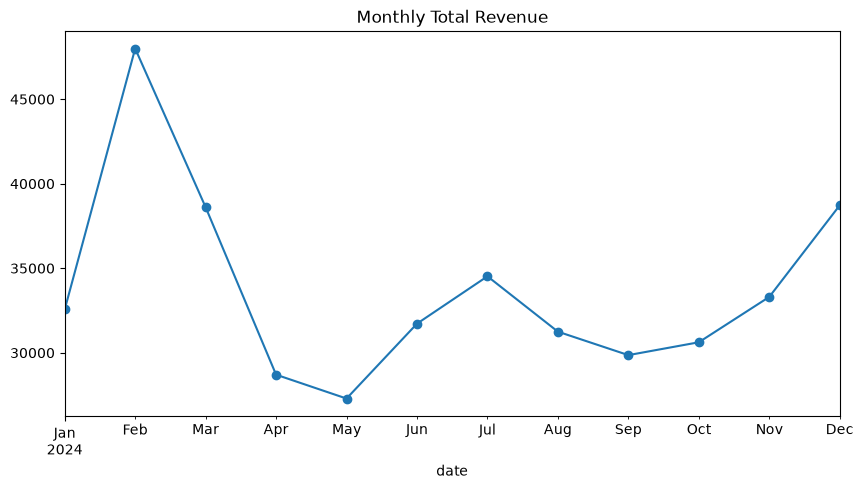

In [59]:
monthly_revenue = (full_data.set_index("date")["revenue"].resample("ME").sum())

monthly_revenue

monthly_revenue.plot(
    kind="line",
    figsize=(10, 5),
    marker="o",
    title="Monthly Total Revenue"
)

• Also resample to weekly, and compare: which frequency shows the trend more clearly, and which shows more
noise?

<Axes: title={'center': 'Weekly Total Revenue'}, xlabel='date'>

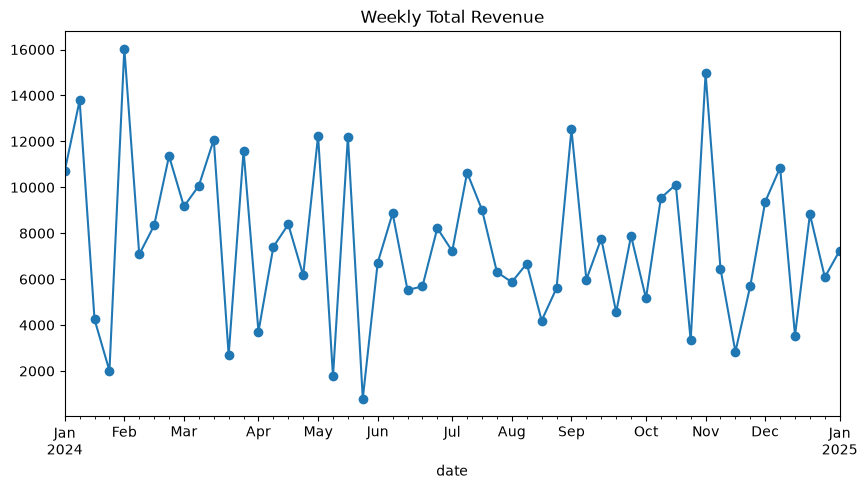

In [65]:
weekly_revenue = (full_data.set_index("date")["revenue"].resample("W").sum())

weekly_revenue

weekly_revenue.plot(
    kind="line",
    figsize=(10, 5),
    marker="o",
    title="Weekly Total Revenue"
)

• Write two sentences on any time patterns you found — a busy day, a peak month, a trend.

==> Sunday was the busiest day of the week, generating the highest total revenue. February was the peak month, 
showing that sales were strongest during this period.


***TASK 05 String operations***

• Using the string accessor (.str), find all products whose name contains a particular word or letter.

In [69]:
products[products['product_name'].str.contains('a', case=False)]

,product_id,product_name,category,unit_price
0,P001,Laptop,Electronics,800
2,P003,Keyboard,Electronics,45
4,P005,Webcam,Electronics,60
5,P006,Headphones,Electronics,120
7,P008,Desk Lamp,Office,40
8,P009,Chair,Office,180
9,P010,Standing Desk,Office,400
12,P013,Backpack,Accessories,55
13,P014,Water Bottle,Accessories,20
14,P015,Phone Stand,Accessories,18


• Create a new column that is the product category in uppercase, and another that is its length.

In [73]:
products['upper_case'] = products['category'].str.upper() 
products['name_len'] = products['product_name'].str.len()
products.head()   

,product_id,product_name,category,unit_price,upper_case,name_len
0,P001,Laptop,Electronics,800,ELECTRONICS,6
1,P002,Mouse,Electronics,25,ELECTRONICS,5
2,P003,Keyboard,Electronics,45,ELECTRONICS,8
3,P004,Monitor,Electronics,250,ELECTRONICS,7
4,P005,Webcam,Electronics,60,ELECTRONICS,6


• Count how many customers' IDs end in a particular digit (or start with a particular pattern).

In [79]:
count = customers["customer_id"].astype(str).str.endswith("5").sum()

print(count)

5


• If any text column has inconsistent capitalisation or extra spaces, clean it with .str.strip() and
.str.lower() or .str.title().

In [83]:
full_data['region'].str.strip().str.title()

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
       ...  
995    South
996    South
997    South
998     West
999     East
Name: region, Length: 1000, dtype: str